In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from plot_openloop import plot_openloop
from plot_estimator import plot_estimator

\begin{align}
    \dot p = \bar\beta(1+x)(1-p)p - \delta p\\
    \tau_x\dot x = -x + \tanh\left((k_p p + k_x x^2 + u_0)x\right)
\end{align}

define the dynamics:

In [ ]:
def SIS_NOD(t, y, beta,delta,kp,kx,u0,tau,w):
    p = y[0]
    x = y[1]
    pdot = beta*(1+x)*(1-p)*p - delta*p
    xdot = (-x +np.tanh((kp*p + kx*x*x + u0)*x)+w)/tau

    return [max(0, min(1, pdot)),max(-1, min(1, xdot))] # keep everything bounded

0.5250000000000001


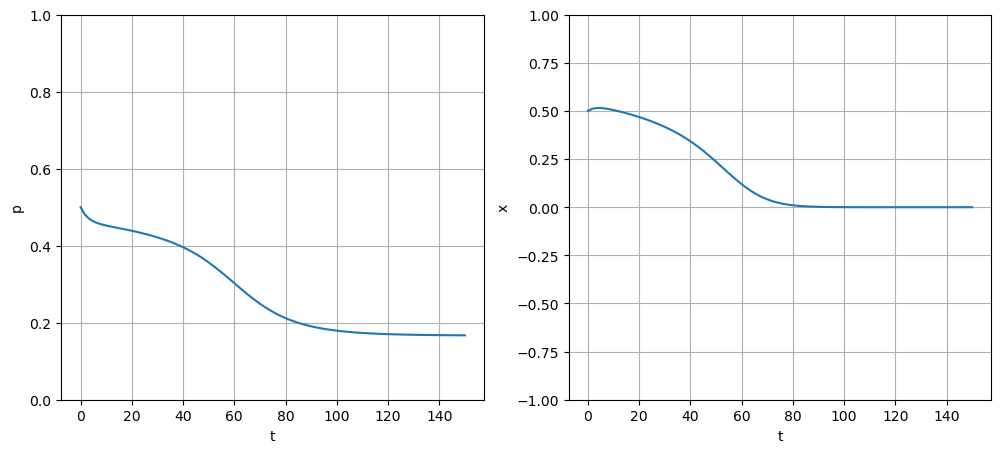

In [ ]:
beta = 0.36
delta = 0.3
kp = 0.7
kx = 0.3
u0 = 0.7
tau = 1
w = 0

betastar = delta*kp/(kp-1+u0)
print(betastar)

y0 = [0.5,0.5]

tspan = [0,150]
t_eval = np.linspace(tspan[0],tspan[1],100)
sol = solve_ivp(SIS_NOD,tspan,y0,args = (beta,delta,kp,kx,u0,tau,w),t_eval = t_eval,method = "LSODA")


fig,ax = plt.subplots(1,2,figsize = (12,5),dpi = 300)
ax[0].plot(sol.t,sol.y[0])
ax[0].set_xlabel("t")
ax[0].set_ylabel("p")
ax[0].set_ylim(0,1)
ax[0].grid()


ax[1].plot(sol.t,sol.y[1])
ax[1].set_xlabel("t")
ax[1].set_ylabel("x")
ax[1].set_ylim(-1,1)
ax[1].grid()

plt.show()

In [ ]:
bp1 = delta
bp2 = 0.36974549
bp3 = betastar